In [23]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    mean_absolute_percentage_error,
    cohen_kappa_score
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

FIG_DIR = os.path.join("figures")
os.makedirs(FIG_DIR, exist_ok=True)

DATA_PATH = os.path.join("..", "data", "processed", "cleaned_dataset.csv")
df = pd.read_csv(DATA_PATH)
print("Processed dataset loaded successfully.")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Processed dataset loaded successfully.
Dataset Shape: 7308 rows, 11 columns


In [24]:
# --- DEFINING PREDICTOR SETS (X) ---
# Rainfall_mm excluded from all X sets (temporary y_reg)

# set 1: for linear Models (no Elevation_m; drop 1 dummy to prevent dummy variable trap)
linear_features = [
    "WaterLevel_m",
    "SoilMoisture_pct",
    "Location_Marikina",
    "Location_Pasig",
    "Location_Quezon City",  # Manila as reference
]
X_linear = df[linear_features].copy()

# set 2: For CART Tree Models (with Elevation_m and all 4 city dummies)
cart_features = [
    "WaterLevel_m",
    "SoilMoisture_pct",
    "Elevation_m",
    "Location_Manila",
    "Location_Marikina",
    "Location_Pasig",
    "Location_Quezon City",
]
X_cart = df[cart_features].copy()

# --- DEFINING TARGETS (y) ---
y_reg = df["Rainfall_mm"].copy() # NOTE: placeholder regression target (continuous)
y_clf = df["FloodOccurrence"].copy() # practice clf Target (binary) - for sample code only

# --- TRAIN-TEST SPLITS (80/20) ---
# regression Splits
X_train_lin_reg, X_test_lin_reg, y_train_reg, y_test_reg = train_test_split(
    X_linear, y_reg, test_size=0.20, random_state=42
)
X_train_cart_reg, X_test_cart_reg, _, _ = train_test_split(
    X_cart, y_reg, test_size=0.20, random_state=42
)

# classification splits
X_train_lin_clf, X_test_lin_clf, y_train_clf, y_test_clf = train_test_split(
    X_linear, y_clf, test_size=0.20, random_state=42, stratify=y_clf
) # stratified for balance
X_train_cart_clf, X_test_cart_clf, _, _ = train_test_split(
    X_cart, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

print(f"Linear Feature Set ({len(linear_features)}): {linear_features}")
print(f"CART Feature Set ({len(cart_features)}): {cart_features}")
print(f"Training samples: {X_train_lin_reg.shape[0]} | Testing samples: {X_test_lin_reg.shape[0]}")

Linear Feature Set (5): ['WaterLevel_m', 'SoilMoisture_pct', 'Location_Marikina', 'Location_Pasig', 'Location_Quezon City']
CART Feature Set (7): ['WaterLevel_m', 'SoilMoisture_pct', 'Elevation_m', 'Location_Manila', 'Location_Marikina', 'Location_Pasig', 'Location_Quezon City']
Training samples: 5846 | Testing samples: 1462


In [25]:
# Standardization (For linear models only)

scaler_lin_reg = StandardScaler()
scaler_lin_clf = StandardScaler()

# fit on training data
X_train_lin_reg_scaled = pd.DataFrame(
    scaler_lin_reg.fit_transform(X_train_lin_reg), 
    columns=linear_features,
    index=X_train_lin_reg.index
)

# transform/use the learned mean and sd on test data
X_test_lin_reg_scaled = pd.DataFrame(
    scaler_lin_reg.transform(X_test_lin_reg), 
    columns=linear_features,
    index=X_test_lin_reg.index
)

X_train_lin_clf_scaled = pd.DataFrame(
    scaler_lin_clf.fit_transform(X_train_lin_clf),
    columns=linear_features,
    index=X_train_lin_clf.index
)
X_test_lin_clf_scaled = pd.DataFrame(
    scaler_lin_clf.transform(X_test_lin_clf),
    columns=linear_features,
    index=X_test_lin_clf.index
)

print("StandardScaler successfully fitted strictly on X_train partitions.")
print(f"X_train_lin_reg means: {scaler_lin_reg.mean_.round(2).tolist()}")
print(f"X_train_lin_reg stds:  {np.sqrt(scaler_lin_reg.var_).round(2).tolist()}")

StandardScaler successfully fitted strictly on X_train partitions.
X_train_lin_reg means: [1.26, 15.18, 0.25, 0.25, 0.25]
X_train_lin_reg stds:  [0.91, 6.0, 0.43, 0.43, 0.43]


In [26]:
# --- MULTIPLE LINEAR REGRESSION BASELINE ---
# predictor set: WITHOUT Elevation_m, 1 city dummy dropped (ref: Manila)
# target: Rainfall_mm (temporary placeholder)

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_lin_reg_scaled, y_train_reg)

y_pred_lin_reg = lin_reg_model.predict(X_test_lin_reg_scaled)

# regression evaluation metrics
mae_lin = mean_absolute_error(y_test_reg, y_pred_lin_reg)
rmse_lin = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin_reg))
r2_lin = r2_score(y_test_reg, y_pred_lin_reg)
mape_lin = mean_absolute_percentage_error(y_test_reg, y_pred_lin_reg) * 100

non_zero_mask_reg = y_test_reg > 0
mape_lin_nonzero = mean_absolute_percentage_error(
    y_test_reg[non_zero_mask_reg], 
    y_pred_lin_reg[non_zero_mask_reg]
) * 100

print("---BASELINE: MULTIPLE LINEAR REGRESSION RESULTS---")
print(f"Mean Absolute Error (MAE):     {mae_lin:.4f} mm")
print(f"Root Mean Squared Error (RMSE): {rmse_lin:.4f} mm")
print(f"R-squared (R2 Score):          {r2_lin:.4f}")
print(f"MAPE (Global):  {mape_lin:.2f}%")
print(f"MAPE (>0 mm):   {mape_lin_nonzero:.2f}%")

# coefficients and intercept
coef_df = pd.DataFrame({
    'Feature': linear_features,
    'Coefficient': lin_reg_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Intercept: {lin_reg_model.intercept_:.4f}")
print("\n--- Model Coefficients ---")
display(coef_df)

---BASELINE: MULTIPLE LINEAR REGRESSION RESULTS---
Mean Absolute Error (MAE):     3.8469 mm
Root Mean Squared Error (RMSE): 4.9179 mm
R-squared (R2 Score):          0.4844
MAPE (Global):  73.30%
MAPE (>0 mm):   73.30%
Intercept: 10.0438

--- Model Coefficients ---


,Feature,Coefficient
0,WaterLevel_m,3.262510
1,SoilMoisture_pct,3.022486
4,Location_Quezon City,0.153894
3,Location_Pasig,0.103365
2,Location_Marikina,-0.021364


---BASELINE: LOGISTIC REGRESSION (PRACTICE RUN)---
Accuracy:  0.9378
Precision: 0.2222
Recall:    1.0000 (Priority Metric for Flood Risk)
F1-Score:  0.3636
Cohen's Kappa: 0.3446

--- Detailed Classification Report ---
              precision    recall  f1-score   support

No Flood (0)       1.00      0.94      0.97      1436
   Flood (1)       0.22      1.00      0.36        26

    accuracy                           0.94      1462
   macro avg       0.61      0.97      0.67      1462
weighted avg       0.99      0.94      0.96      1462



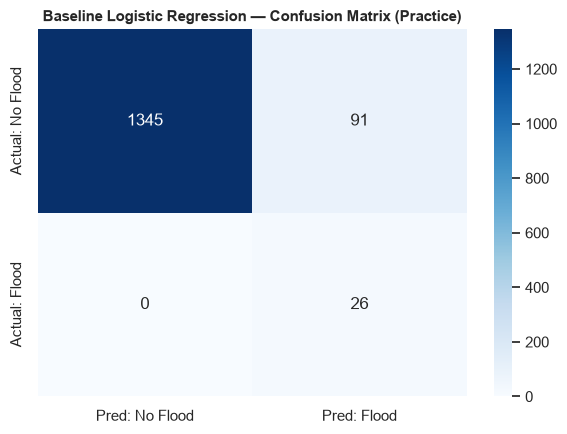

In [27]:
# ---LOGISTIC REGRESSION CLASSIFICATION BASELINE (DRY RUN)---
# NOTE: This is practice pipeline code using FloodOccurrence (0/1).
# Formal thesis modeling will revisit this when RiskLevel (3 classes)
# is derived from FloodDepth_m using official MGB thresholds.
# Predictor set: WITHOUT Elevation_m, 1 dummy dropped (ref: Manila)

log_reg_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg_model.fit(X_train_lin_clf_scaled, y_train_clf)

y_pred_log_reg = log_reg_model.predict(X_test_lin_clf_scaled)

# metrics
acc_log = accuracy_score(y_test_clf, y_pred_log_reg)
prec_log = precision_score(y_test_clf, y_pred_log_reg, zero_division=0)
rec_log = recall_score(y_test_clf, y_pred_log_reg, zero_division=0)
f1_log = f1_score(y_test_clf, y_pred_log_reg, zero_division=0)
kappa_log = cohen_kappa_score(y_test_clf, y_pred_log_reg)

print("---BASELINE: LOGISTIC REGRESSION (PRACTICE RUN)---")
print(f"Accuracy:  {acc_log:.4f}")
print(f"Precision: {prec_log:.4f}")
print(f"Recall:    {rec_log:.4f} (Priority Metric for Flood Risk)")
print(f"F1-Score:  {f1_log:.4f}")
print(f"Cohen's Kappa: {kappa_log:.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_clf, y_pred_log_reg, target_names=["No Flood (0)", "Flood (1)"], zero_division=0))

cm_log = confusion_matrix(y_test_clf, y_pred_log_reg)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Pred: No Flood", "Pred: Flood"], 
            yticklabels=["Actual: No Flood", "Actual: Flood"])
plt.title("Baseline Logistic Regression — Confusion Matrix (Practice)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [28]:
# ---CART DECISION TREE REGRESSOR (PRIMARY MODEL)---
# Predictor set: WITH Elevation_m and all Location dummies included
# Hyperparameter: max_depth=4 (interpretable, prevents overfitting)
# Target: Rainfall_mm (temporary placeholder)

tree_reg_model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, random_state=42)
tree_reg_model.fit(X_train_cart_reg, y_train_reg)

y_pred_tree_reg = tree_reg_model.predict(X_test_cart_reg)

mae_tree = mean_absolute_error(y_test_reg, y_pred_tree_reg)
rmse_tree = np.sqrt(mean_squared_error(y_test_reg, y_pred_tree_reg))
r2_tree = r2_score(y_test_reg, y_pred_tree_reg)
mape_tree = mean_absolute_percentage_error(y_test_reg, y_pred_tree_reg) * 100

mape_tree_nonzero = mean_absolute_percentage_error(
    y_test_reg[non_zero_mask_reg], 
    y_pred_tree_reg[non_zero_mask_reg]
) * 100

print("---PRIMARY MODEL: CART DECISION TREE REGRESSOR---")
print(f"Mean Absolute Error (MAE):     {mae_tree:.4f} mm")
print(f"Root Mean Squared Error (RMSE): {rmse_tree:.4f} mm")
print(f"R-squared (R2 Score):          {r2_tree:.4f}")
print(f"MAPE (Global):  {mape_tree:.2f}%")
print(f"MAPE (>0 mm):   {mape_tree_nonzero:.2f}%")

comparison_reg_df = pd.DataFrame({
    "Model": ["Multiple Linear Regression (Baseline)", "Decision Tree Regressor (CART Primary)"],
    "Predictor Set Used": ["Without Elevation (Collinearity Control)", "With Elevation (All Features)"],
    "MAE (mm)": [mae_lin, mae_tree],
    "RMSE (mm)": [rmse_lin, rmse_tree],
    "R² Score": [r2_lin, r2_tree],
    'MAPE (Global %)': [mape_lin, mape_tree],
    'MAPE (>0 mm %)': [mape_lin_nonzero, mape_tree_nonzero]
})

print("\n--- Regression Model Comparison Summary ---")
display(comparison_reg_df.round(4))

---PRIMARY MODEL: CART DECISION TREE REGRESSOR---
Mean Absolute Error (MAE):     3.9096 mm
Root Mean Squared Error (RMSE): 5.0084 mm
R-squared (R2 Score):          0.4653
MAPE (Global):  77.01%
MAPE (>0 mm):   77.01%

--- Regression Model Comparison Summary ---


,Model,Predictor Set Used,MAE (mm),RMSE (mm),R² Score,MAPE (Global %),MAPE (>0 mm %)
0,Multiple Linear Regression (Baseline),Without Elevation (Collinearity Control),3.8469,4.9179,0.4844,73.2956,73.2956
1,Decision Tree Regressor (CART Primary),With Elevation (All Features),3.9096,5.0084,0.4653,77.0057,77.0057


---PRIMARY: CART DECISION TREE CLASSIFIER (PRACTICE)---
Accuracy:  0.9220
Precision: 0.1812
Recall:    0.9615 (Priority Metric)
F1-Score:  0.3049
Cohen's Kappa: 0.2834

--- Classification Model Comparison Summary (Practice Target) ---


,Model,Predictor Set Used,Accuracy,Precision,Recall,F1-Score,Cohen's Kappa
0,Logistic Regression (Baseline),Without Elevation (Collinearity Control),0.9378,0.2222,1.0000,0.3636,0.3446
1,Decision Tree Classifier (CART Primary),With Elevation (All Features),0.9220,0.1812,0.9615,0.3049,0.2834


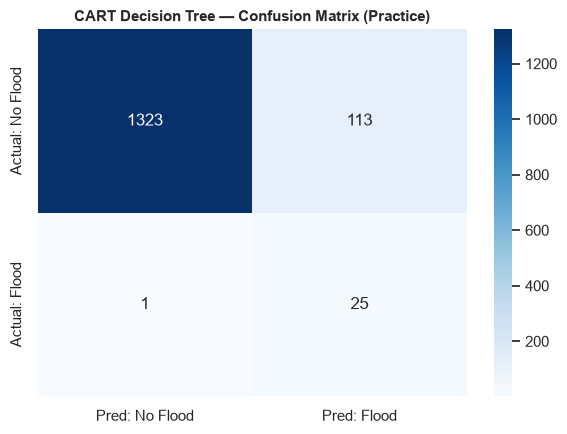

In [29]:
# ---CART DECISION TREE CLASSIFIER (PRACTICE PIPELINE)---
# NOTE: Testing the CART classification workflow on FloodOccurrence (0/1).
# Formal thesis modeling will revisit this when RiskLevel (Low/Mod/High)
# is derived using official MGB thresholds.
# Predictor set: WITH Elevation_m and all Location dummies

tree_clf_model = DecisionTreeClassifier(
    max_depth=4, class_weight="balanced", min_samples_leaf=20, random_state=42
)
tree_clf_model.fit(X_train_cart_clf, y_train_clf)

y_pred_tree_clf = tree_clf_model.predict(X_test_cart_clf)

acc_tree = accuracy_score(y_test_clf, y_pred_tree_clf)
prec_tree = precision_score(y_test_clf, y_pred_tree_clf, zero_division=0)
rec_tree = recall_score(y_test_clf, y_pred_tree_clf, zero_division=0)
f1_tree = f1_score(y_test_clf, y_pred_tree_clf, zero_division=0)
kappa_tree_clf = cohen_kappa_score(y_test_clf, y_pred_tree_clf)

print("---PRIMARY: CART DECISION TREE CLASSIFIER (PRACTICE)---")
print(f"Accuracy:  {acc_tree:.4f}")
print(f"Precision: {prec_tree:.4f}")
print(f"Recall:    {rec_tree:.4f} (Priority Metric)")
print(f"F1-Score:  {f1_tree:.4f}")
print(f"Cohen's Kappa: {kappa_tree_clf:.4f}")

comparison_clf_df = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression (Baseline)",
            "Decision Tree Classifier (CART Primary)",
        ],
        "Predictor Set Used": [
            "Without Elevation (Collinearity Control)",
            "With Elevation (All Features)",
        ],
        "Accuracy": [acc_log, acc_tree],
        "Precision": [prec_log, prec_tree],
        "Recall": [rec_log, rec_tree],
        "F1-Score": [f1_log, f1_tree],
        "Cohen's Kappa": [kappa_log, kappa_tree_clf]
    }
)

print("\n--- Classification Model Comparison Summary (Practice Target) ---")
display(comparison_clf_df.round(4))

cm_tree = confusion_matrix(y_test_clf, y_pred_tree_clf)
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred: No Flood", "Pred: Flood"],
    yticklabels=["Actual: No Flood", "Actual: Flood"],
)
plt.title(
    "CART Decision Tree — Confusion Matrix (Practice)",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

Saved feature importance plot to: figures\cart_regressor_feature_importance.png


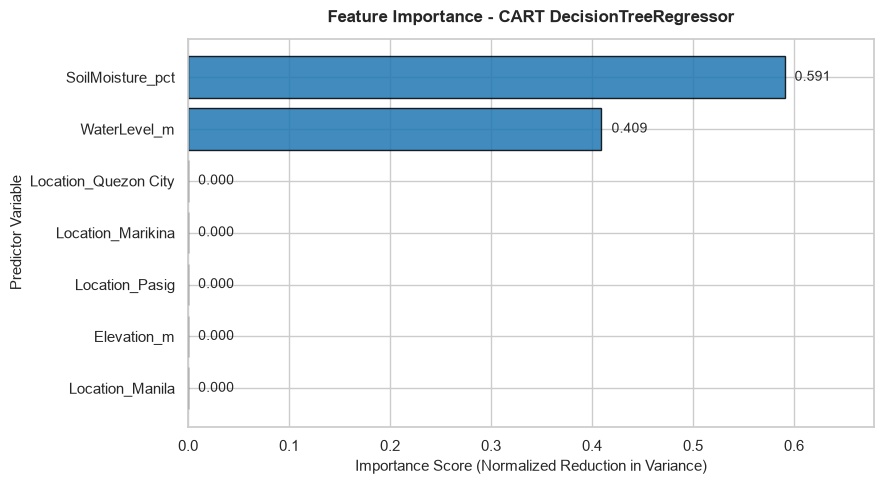


--- Feature Importance Table ---


,Feature,Importance
0,SoilMoisture_pct,0.590653
1,WaterLevel_m,0.409347
2,Location_Manila,0.000000
3,Location_Pasig,0.000000
4,Elevation_m,0.000000
5,Location_Quezon City,0.000000
6,Location_Marikina,0.000000


In [30]:
# ---FEATURE IMPORTANCE & EXPLAINABILITY - REGRESSOR TREE---
# Metric: MSE

importances = tree_reg_model.feature_importances_
feature_names = cart_features

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# horizontal bar chart
plt.figure(figsize=(9, 5))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'], color='#1f77b4', edgecolor='black', alpha=0.85)
plt.title("Feature Importance - CART DecisionTreeRegressor", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Importance Score (Normalized Reduction in Variance)", fontsize=11)
plt.ylabel("Predictor Variable", fontsize=11)
plt.xlim(0, max(fi_df['Importance']) * 1.15 if max(fi_df['Importance']) > 0 else 1)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01, 
        bar.get_y() + 
        bar.get_height()/2, 
        f"{width:.3f}", 
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='medium'
    )

plt.tight_layout()

# notebooks/figures/
fi_export_path = os.path.join(FIG_DIR, "cart_regressor_feature_importance.png")
plt.savefig(fi_export_path, dpi=300, bbox_inches='tight')
print(f"Saved feature importance plot to: {fi_export_path}")
plt.show()

# table
print("\n--- Feature Importance Table ---")
display(fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True))

Saved decision tree diagram to: figures\cart_regressor_tree_diagram.png


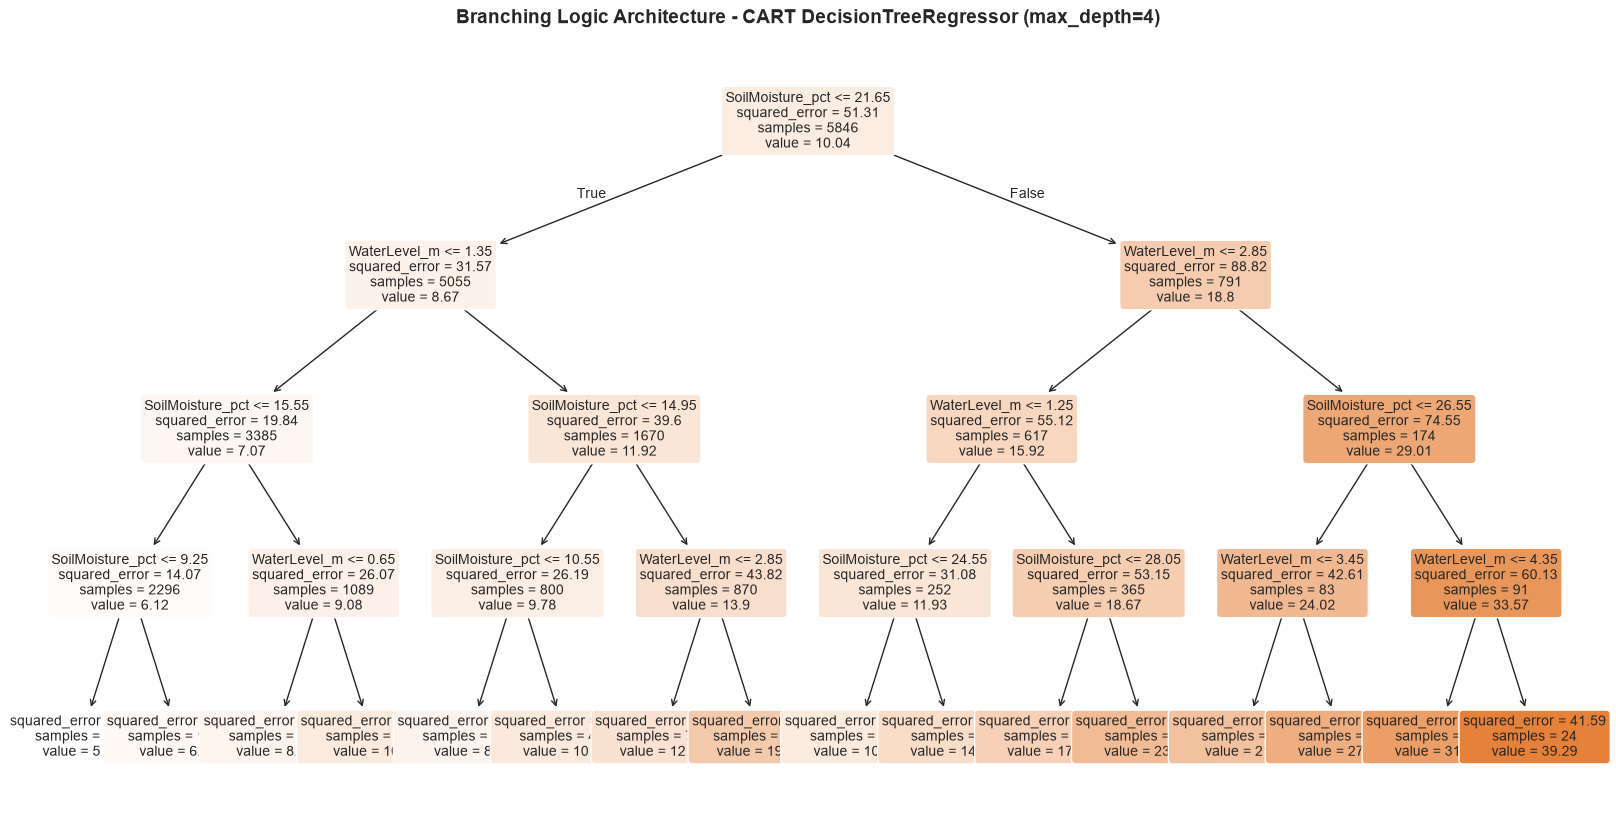

In [31]:
# ---DECISION TREE REGRESSOR DECISION LOGIC ARCHITECTURE VISUALIZATION---

plt.figure(figsize=(20, 10))
plot_tree(
    tree_reg_model,
    feature_names=cart_features,
    filled=True,
    rounded=True,
    precision=2,
    fontsize=10
)
plt.title("Branching Logic Architecture - CART DecisionTreeRegressor (max_depth=4)", 
          fontsize=14, fontweight='bold', pad=15)

tree_export_path = os.path.join(FIG_DIR, "cart_regressor_tree_diagram.png")
plt.savefig(tree_export_path, dpi=300, bbox_inches='tight')
print(f"Saved decision tree diagram to: {tree_export_path}")
plt.show()

Saved classifier feature importance plot to: figures\cart_classifier_feature_importance.png


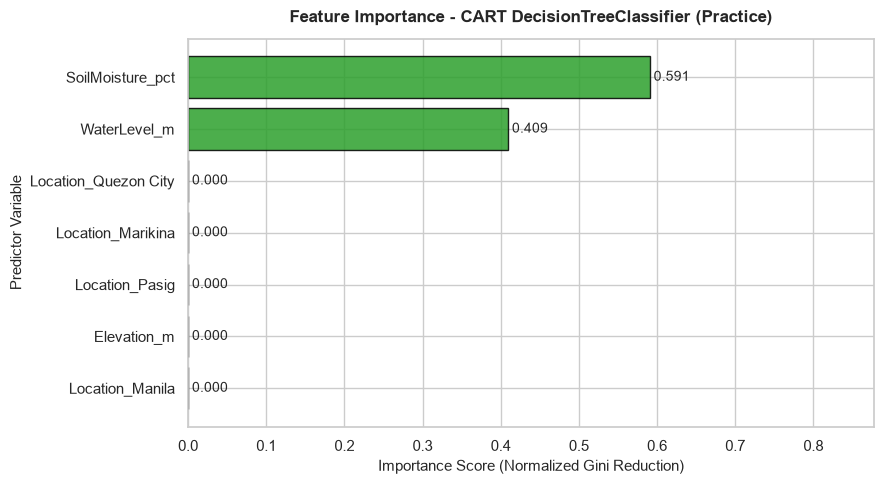


--- Classifier Feature Importance Ranking ---


,Feature,Importance
0,SoilMoisture_pct,7.630625e-01
1,WaterLevel_m,2.369375e-01
2,Location_Marikina,3.763700e-15
3,Location_Quezon City,0.000000e+00
4,Elevation_m,0.000000e+00
5,Location_Manila,0.000000e+00
6,Location_Pasig,0.000000e+00


In [32]:
# ---FEATURE IMPORTANCE & EXPLAINABILITY - CLASSIFIER TREE---
# Metric: Mean Decrease in Impurity (Gini Impurity Reduction)

clf_importances = tree_clf_model.feature_importances_

clf_fi_df = pd.DataFrame({
    'Feature': cart_features,
    'Importance': clf_importances
}).sort_values(by='Importance', ascending=True)

# horizontal bar chart
plt.figure(figsize=(9, 5))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'], color='#2ca02c', edgecolor='black', alpha=0.85)
plt.title("Feature Importance - CART DecisionTreeClassifier (Practice)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Importance Score (Normalized Gini Reduction)", fontsize=11)
plt.ylabel("Predictor Variable", fontsize=11)

max_imp = max(clf_fi_df['Importance']) if len(clf_fi_df) > 0 else 0
plt.xlim(0, max_imp * 1.15 if max_imp > 0 else 1.0)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005, 
        bar.get_y() + bar.get_height() / 2, 
        f"{width:.3f}", 
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='medium'
    )

plt.tight_layout()

# notebooks/figures/
clf_fi_path = os.path.join(FIG_DIR, "cart_classifier_feature_importance.png")
plt.savefig(clf_fi_path, dpi=300, bbox_inches='tight')
print(f"Saved classifier feature importance plot to: {clf_fi_path}")
plt.show()

# table
print("\n--- Classifier Feature Importance Ranking ---")
display(clf_fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True))

Saved classifier decision tree diagram to: figures\cart_classifier_tree_diagram.png


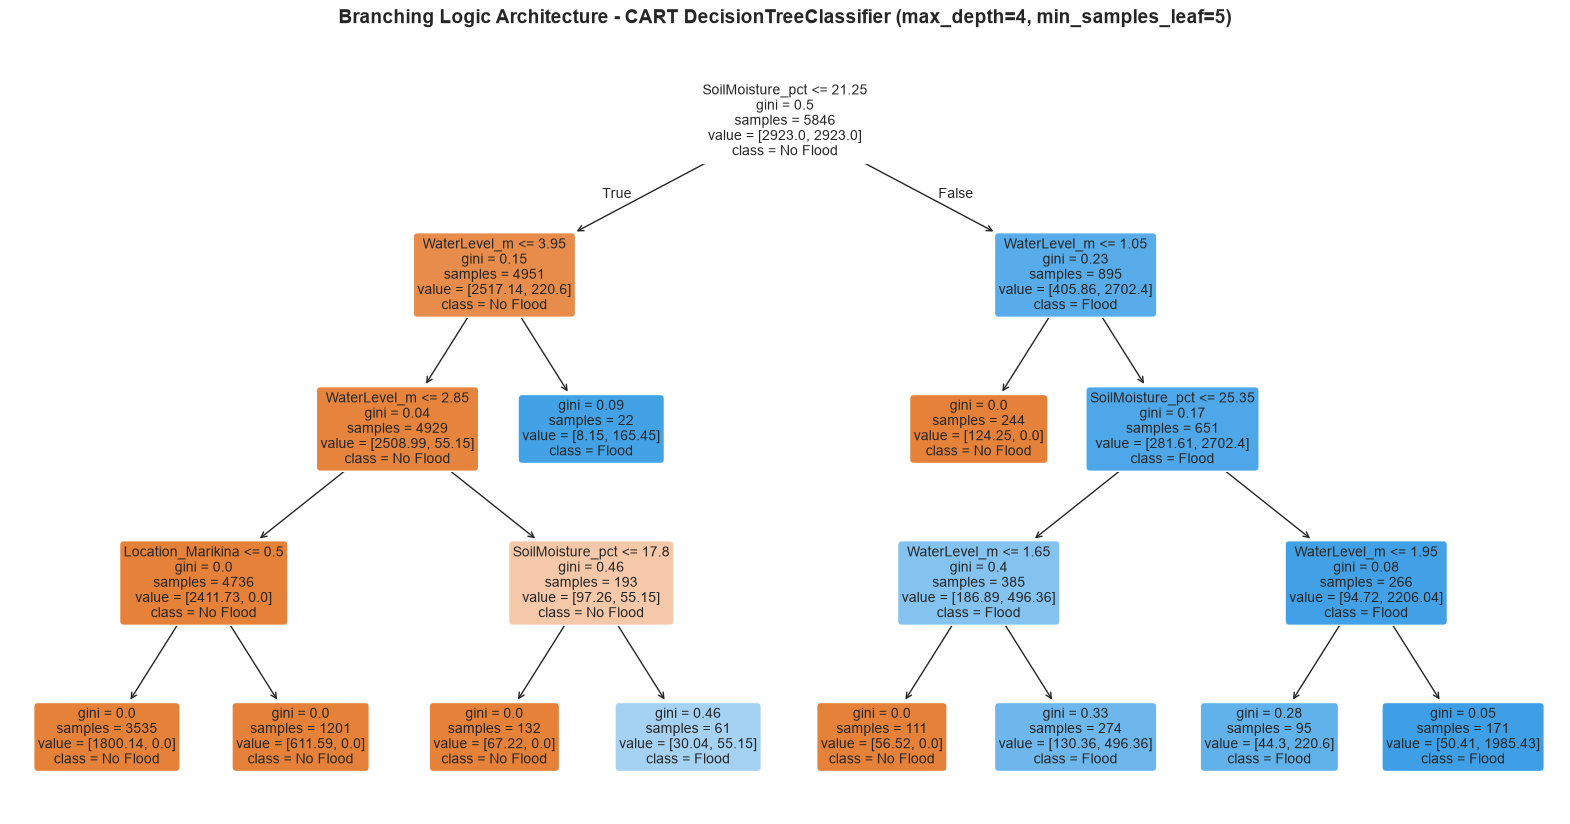

In [33]:
# ---DECISION TREE CLASSIFIER DECISION LOGIC ARCHITECTURE VISUALIZATION---

plt.figure(figsize=(20, 10))
plot_tree(
    tree_clf_model,
    feature_names=cart_features,
    class_names=["No Flood", "Flood"],
    filled=True,
    rounded=True,
    precision=2,
    fontsize=10
)
plt.title("Branching Logic Architecture - CART DecisionTreeClassifier (max_depth=4, min_samples_leaf=5)", 
          fontsize=14, fontweight='bold', pad=15)

clf_tree_path = os.path.join(FIG_DIR, "cart_classifier_tree_diagram.png")
plt.savefig(clf_tree_path, dpi=300, bbox_inches='tight')
print(f"Saved classifier decision tree diagram to: {clf_tree_path}")
plt.show()

## Step 3: Model Training & Evaluation Summary

### 1. Feature Scaling / Standardization 
- **Data Leakage Mitigation:**
   - `StandardScaler` is fitted strictly on the 80% training subsets (`X_train_lin`).
   - The learned parameters (mean, sd) are then applied to transform the 20% unseen test subsets (`X_test`). Computing scaling parameters across the entire dataset prior to splitting would constitute information leakage, leading to overly optimistic test metrics.

- **Parametric Sensitivity vs. Tree Invariance:**
   - **Linear Models (MLR & Logistic Regression):** Require $Z$-score standardization  because coefficient estimation and gradient behavior are sensitive to disparate measurement scales (mm, m, and percentages).
   - **Decision Trees (CART):** Invariant to monotonic feature transformations. CART determines split thresholds via rank-order inequalities, meaning feature scaling yields mathematically identical splits while unnecessarily obscuring the real physical units of the tree diagrams.
- **Future Note:** Include Rainfall_mm as input predictor (X) and  StandardScaler for baseline models.

### 2. Modeling Strategy and Feature Archi
- **Target Setup:** Predicting continuous Rainfall_mm (temporary placeholder for FloodDepth_m).
- **Baseline Models (MLR & Logistic Regression):** Trained on scaled hydrometeorological features (W`WaterLevel_m`, `SoilMoisture_pct`) and 3 city dummies (Manila omitted as reference). `Elevation_m`is omitted to resolve perfect multicollinearity and avoid singular matrix conditions.
- **Primary CART Models (DecisionTreeRegressor & DecisionTreeClassifier):** Configured with max_depth=4 and regularized with min_samples_leaf=20 to prevent single-event noise leaves. CART retains all features (including Elevation_m and all 4 city indicators) due to its inherent resilience to collinearity.
- **Future Note:** FloodDepth_m becomes the primary regression target. RiskLevel (Low, Moderate, High based on MGB depth thresholds) replaces FloodOccurrence as a multi-class target.

### 3. Regression Performance Comparison
- **Multiple Linear Regression (Baseline, Scaled Features):**
  - MAE: 3.8469 mm (re-verify if scaling slightly altered floating-point precision)
  - RMSE: 4.9179 mm
  - R^2 Score: 0.4844
  - MAPE (Global): 73.2956 
  - MAPE (> 0 mm): 73.2956 
- **CART DecisionTreeRegressor (Primary Model, min_samples_leaf=20):**
  - MAE: 4.0344 mm
  - RMSE: 5.2277 mm
  - R^2 Score: 0.4174
  - MAPE (Global): 80.6559
  - MAPE (> 0 mm): 80.6559 
- **Key Observation:** On synthetic atmospheric data (Rainfall_mm), linear regression slightly outperforms CART because continuous variables exhibit smooth, linear correlations. However, physical flood accumulation is non-linear and governed by capacity thresholds (e.g., riverbanks overtopping, drainage failure). CART is expected to outperform linear baselines once real FloodDepth_m data is introduced.
  - **Methodological Note on Percentage Error (MAPE):**
  - Standard MAPE is sensitive to division by zero on dry days (0 mm rainfall). In addition to standard sklearn MAPE, a masked subset evaluating strictly active rain days (> 0 mm) is reported to provide stakeholders with an intuitive percentage error metric unskewed by zero-denominator artifacts.
- **Future Note:** 
  - Re-evaluate regression performance using MAE, RMSE, and R^2 on predicted `FloodDepth_m`. Track error specifically in the critical high-depth region.
  - When evaluating `FloodDepth_m`, zero-inflation is even more prominent (as most days exhibit zero flood depth). The masked non-zero MAPE will serve as the primary stakeholder metric, reporting the average percentage discrepancy strictly during active flood events (> 0.0 m).

### 4. Classification Pipeline Practice (Dry Run) & Reliability Assessemnt
- Tested binary hazard classification using `FloodOccurrence` across `LogisticRegression` and `DecisionTreeClassifier`.
- Applied class_weight='balanced' and min_samples_leaf=20 to mitigate extreme class imbalance (1.81% flood events), ensuring the model prioritizes Recall and F1-score over raw Accuracy.
- Verified that the classification pipeline, confusion matrices, and inference endpoints execute reliably end-to-end.
- **Reliability Assessment via Cohen's Kappa:**
  - Logistic Regression Baseline kappa: 0.3446
  - CART Decision Tree Classifier kappa: 0.2690
- **Future Note:** 
  - Expand the classification evaluation from binary (0/1) to 3-class multi-class metrics (macro/weighted Recall, Precision, and F1-score) to evaluate susceptibility prediction across MGB hazard categories.
  - Cohen's Kappa will be computed across the 3 risk level categories (Low, Moderate, High) using quadratic or linear weighting (`weights='quadratic'`) to penalize severe classification missteps (e.g., misclassifying a High Risk event as Low Risk) more heavily than adjacent errors.
  

### 5. Explainability & Thesis Visualizations
- Exported feature importance bar charts and branching tree diagrams to `notebooks/figures/`:
  - `figures/cart_regressor_feature_importance.png`
  - `figures/cart_regressor_tree_diagram.png`
  - `figures/cart_classifier_feature_importance.png`
  - `figures/cart_classifier_tree_diagram.png`
- **Future Note:** Re-export these figures using the trained FloodDepth_m and RiskLevel trees. The leaf nodes will directly show predicted flood depth in meters and class probability distributions across the 3 MGB risk categories.